# Baird's Counterexample

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
class BairdsEnv(gym.Env):
    def __init__(self):
        super(BairdsEnv, self).__init__()
        self.state = None
        self.observation_space = gym.spaces.Dict({
            "state":gym.spaces.Box(low=0, high=6, shape=(1,), dtype=np.int32)
        })

        self.action_space = gym.spaces.Discrete(n=2)

    def reset(self):
        self.state = int(self.observation_space.sample()['state'][0])
        return self.state

    def step(self, action):
        if action == 0:
            # the action is a "solid" action
            self.state = 6
        elif action == 1:
            # the action is a "dashed" action
            self.state = np.random.choice(6)

        return self.state, 0.0

## Uniform distribution

In [3]:
def target_policy(state):
    return 0

def behaviour_policy(state):
    return int(np.random.choice([0, 1], p=[1/7, 6/7]))

def importance_sampling_ratio(state, action):
    if action == 0:
        target_p = 1.0
        behaviour_p = 1/7
    else:
        target_p = 0.0
        behaviour_p = 6/7

    return target_p / behaviour_p

def transition_probability(next_state, state, action):
    if action == 0 and next_state < 6:
        return 0.0
    elif action == 0 and next_state == 6:
        return 1.0

    if action == 1 and next_state == 6:
        return 0.0
    elif action == 1 and next_state < 6:
        return 1/6
    return 0.0

def feature_vector(state:int):
    if state < 6:
        vector = np.zeros(8, dtype=np.float32)
        vector[state] = 2
        vector[7] = 1
        return vector

    vector = np.zeros(8, dtype=np.float32)
    vector[state] = 1
    vector[7] = 2
    return vector

def plot(history:list[np.ndarray], ax, x_label, title):
    history = np.concat([h[None, ...] for h in history], axis=0)
    for i in range(8):
        ax.plot(history[:, i])
    
    ax.set_xticks([0, 1000]);
    ax.set_yticks([1, 10, 100, 200, 300]);
    ax.spines.pop('right')
    ax.spines.pop('top')
    ax.set_title(title, fontdict={'fontweight':400, 'fontsize':16})
    ax.set_xlabel(x_label)
    ax.set_ylim([0, 350])

### Semi-gradient TD(0)

In [4]:
def semi_gradient_td(
    steps:int,
    env:BairdsEnv,
    w:np.ndarray,
    alpha:float=0.01,
    gamma:float=0.99
):
    w:np.ndarray = w.copy()
    history = [w]
    state = env.reset()
    for step in range(steps):
        action = behaviour_policy(state)
        new_state, reward = env.step(action)

        x_state = feature_vector(state)
        x_new_state = feature_vector(new_state)
        td_error = reward + gamma * (w.T @ x_new_state) - (w.T @ x_state)
        rho = importance_sampling_ratio(state, action)
        w = w + alpha * rho * td_error * x_state
        state = new_state
        history.append(w)

    return w, history

In [5]:
def dynamic_programming(
    sweeps:int,
    w:np.ndarray,
    alpha:float=0.01,
    gamma:float=0.99
):
    w:np.ndarray = w.copy()
    history = [w]
    for sweep in range(sweeps):
        update = 0
        for state in range(7):
            state_update = 0
            for action in [0, 1]:
                for next_state in range(7):
                    tp = transition_probability(next_state, state, action)
                    action_prob = 1.0 if action == 0 else 0.0
                    x_state = feature_vector(state)
                    x_next_state = feature_vector(next_state)
                    state_update += tp * action_prob * (0.0 + gamma * (w.T @ x_next_state))
            state_update = (state_update - (w.T @ x_state)) * x_state
            update += state_update
        w = w + (alpha / 7) * update
        history.append(w)

    return w, history

In [6]:
w = np.array([1, 1, 1, 1, 1, 1, 10, 1])
w_td, td_history = semi_gradient_td(1000, BairdsEnv(), w=w)
w_dp, dp_history = dynamic_programming(1000, w=w)

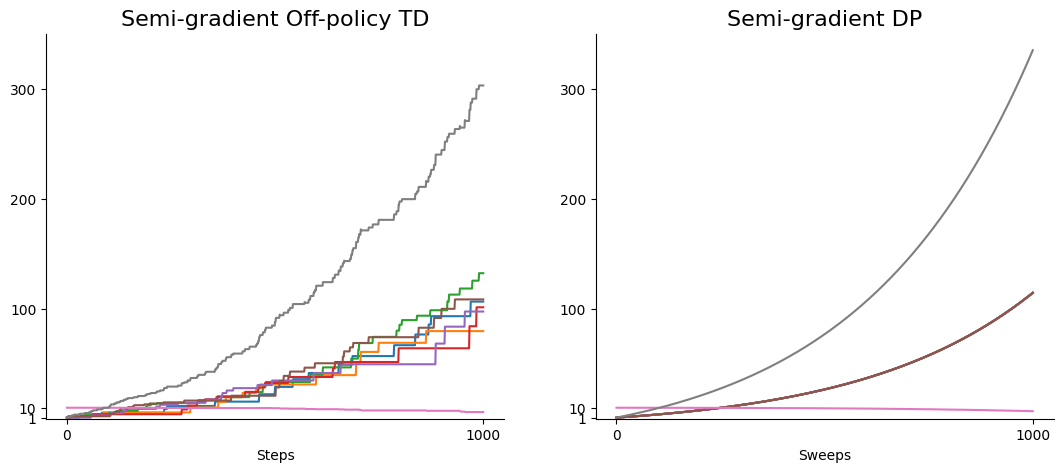

In [7]:
fig = plt.figure(figsize=(13, 5))
ax = plt.subplot(121)
plot(td_history, ax, 'Steps', 'Semi-gradient Off-policy TD')
ax = plt.subplot(122)
plot(dp_history, ax, 'Sweeps', 'Semi-gradient DP')

## On-policy distribution
The problem with the above algorithm is the fact that updates are generated according to the on-policy distribution. For semi-gradient Off-policy TD, we are using importance sampling ratio to make the expectation for the td-error according to the target policy and not the behaviour policy. However, every state is updated as frequently as the behaviour policy visits them. Baird's counter example shows this problem clearly. Even if we use expected updates as we do in dynamic programming, divergence would be unavoidable.

However, we'll show below that generating updates according to the on-policy behaviour gaurantees divergence. Note that, the semi-gradient dynamic programming above, generates updates according to the uniform distribution.

In [8]:
def dynamic_programming_on_policy(
    steps:int,
    env:BairdsEnv,
    w:np.ndarray,
    alpha:float=0.01,
    gamma:float=0.99
):
    w:np.ndarray = w.copy()
    history = [w]
    state = env.reset()
    for step in range(steps):
        action = behaviour_policy(state)
        next_state, reward = env.step(action)
        x_next_state = feature_vector(next_state)
        x_state = feature_vector(state)

        expectation = 0
        for action in [0, 1]:
            for next_state in range(7):
                tp = transition_probability(next_state, state, action)
                action_prob = 1.0 if action == 0 else 0.0 # according to pi
                expectation += tp * action_prob * (0.0 + gamma * (w.T @ x_next_state))

        w = w + alpha * (expectation - (w.T @ x_state)) * x_state
        state = next_state
        history.append(w)

    return w, history

In [9]:
w = np.array([1, 1, 1, 1, 1, 1, 10, 1])
w_dp, dp_history = dynamic_programming(1000, w=w)
w_dp_op, dp_op_history = dynamic_programming_on_policy(10000, BairdsEnv(), w=w)

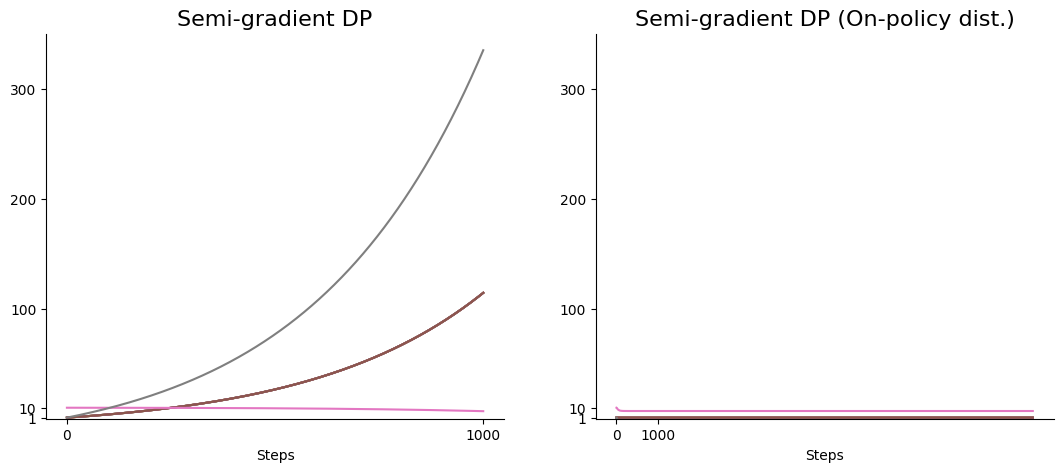

In [12]:
fig = plt.figure(figsize=(13, 5))
ax = plt.subplot(121)
plot(dp_history, ax, 'Steps', 'Semi-gradient DP')
ax = plt.subplot(122)
plot(dp_op_history, ax, 'Steps', 'Semi-gradient DP (On-policy dist.)')